In [1]:
from fpl_project.scripts import config
from fpl_project.scripts.data_utils.features_config import FeaturesConfig
from fpl_project.scripts.model_utils.data import FPLDataPipe, train_test_split
from fpl_project.scripts.model_utils.trainer import set_seed
from fpl_project.scripts.model_utils.selector import ModelSelector, initialize_device

from typing import NamedTuple
from dataclasses import dataclass
from typing import Any, Dict
from fpl_project.scripts.model_utils.models import FPLLoss

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import pandas as pd
import scipy.stats as stats

pd.set_option('display.max_columns', None)

from sklearn.ensemble import RandomForestRegressor
import xgboost
import catboost

import torch

import numpy as np
import seaborn as sns
sns.set_style("whitegrid")

import matplotlib.pyplot as plt

import glum

In [5]:
device = initialize_device()
device

'cuda'

In [6]:
set_seed(77)
data = pd.read_parquet("/home/onyxia/work/FPL/Data/fpl_data.parquet")
data.total_points = data.total_points.clip(lower=0)

In [7]:
cols_map = FeaturesConfig()
ignored_num = {"name", "position", "element", "opponent_team", "gw", "code", "season", "kickoff_time", "team"}
ignored_cat = {"web_name", "player_id", "gw"}
data_cols_set = set(data.columns)

ema_lagg_cols = [c for c in data.columns if "ema" in c or "lagg" in c]
pre_game_filtered = [c for c in getattr(cols_map, "pre_game_cols") if c in data_cols_set and c not in ignored_num]
num_cols = list(dict.fromkeys(ema_lagg_cols + pre_game_filtered))
cat_cols = [c for c in getattr(cols_map, "static_cols") if c in data_cols_set and c not in ignored_cat]



fpl_data_pipe = FPLDataPipe(num_cols=num_cols, cat_cols=cat_cols)


In [8]:
data_splits = train_test_split(data)


In [9]:
data_splits.keys()

dict_keys(['X_train', 'y_train', 'X_valid', 'y_valid', 'X_test', 'y_test'])

In [43]:
glm = glum.GeneralizedLinearRegressor(
    family="tweedie",
    link="auto", 
    alpha=5,
    l1_ratio=0.5,
    
)

In [44]:
glm.fit(X=data_splits.get("X_train"), y=data_splits.get("y_train"))

/opt/python/lib/python3.13/site-packages/tabmat/constructor.py:179: UserWarning: Columns ['team', 'kickoff_time', 'name', 'opponent_team', 'position'] were ignored. Make sure they have a valid dtype.
  warnings.warn(


,alpha,5
,l1_ratio,0.5
,family,'tweedie'
,P1,'identity'
,P2,'identity'
,fit_intercept,True
,link,'auto'
,solver,'auto'
,max_iter,100
,max_inner_iter,100000
,gradient_tol,None


In [45]:
glm.score(X=data_splits.get("X_test"), y=data_splits.get("y_test"))

/opt/python/lib/python3.13/site-packages/tabmat/constructor.py:179: UserWarning: Columns ['team', 'kickoff_time', 'name', 'opponent_team', 'position'] were ignored. Make sure they have a valid dtype.
  warnings.warn(


0.35902145315792755

In [55]:
[c for c in data_splits.get("X_test").columns if "xp" in c]

['player_match_xg_expected',
 'player_match_xa_expected',
 'xp_ema_3',
 'player_match_xg_expected_ema_3',
 'player_match_xa_expected_ema_3',
 'player_match_xg_expected_lagged_1',
 'player_match_xa_expected_lagged_1',
 'xp_lagged_2',
 'player_match_xg_expected_lagged_2',
 'player_match_xa_expected_lagged_2',
 'xp_lagged_3',
 'player_match_xg_expected_lagged_3',
 'player_match_xa_expected_lagged_3',
 'xp_lagged_5',
 'player_match_xg_expected_lagged_5',
 'player_match_xa_expected_lagged_5',
 'xp_std_3',
 'player_match_xg_expected_std_3',
 'player_match_xa_expected_std_3',
 'xp_std_5',
 'player_match_xg_expected_std_5',
 'player_match_xa_expected_std_5',
 'xp_std_8',
 'player_match_xg_expected_std_8',
 'player_match_xa_expected_std_8']

In [46]:
y_pred = glm.predict(data_splits.get("X_test"))

/opt/python/lib/python3.13/site-packages/tabmat/constructor.py:179: UserWarning: Columns ['team', 'kickoff_time', 'name', 'opponent_team', 'position'] were ignored. Make sure they have a valid dtype.
  warnings.warn(


<Axes: ylabel='Count'>

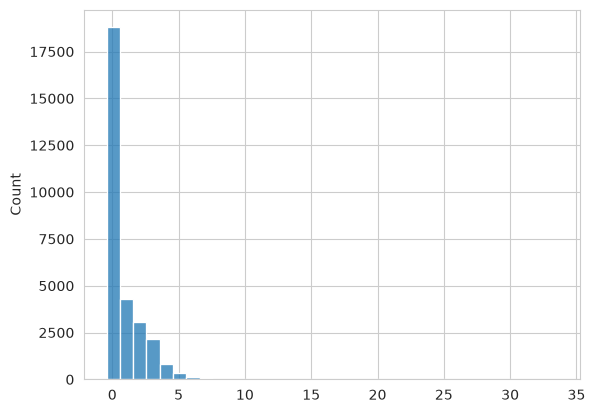

In [51]:
sns.histplot(x=y_pred, discrete=True)